# 07. 정량 평가 (BLEU / ROUGE-L / Distinct-n / 빈 응답 비율)

**작성일**: 2026-09-19

**목표**: 03~06번에서 만든 모델들을 **같은 test set, 같은 지표, 같은 디코딩 기준**으로 한 표에 모아 비교한다.

지금까지의 판단 근거는 validation loss(03/04/06번)와 8개 샘플 정성 비교(04/05번)뿐이었다. 그런데 loss는 "정답 토큰에 얼마나 높은 확률을 줬는가"를 잴 뿐, 실제로 생성된 문장이 좋은지는 직접 재지 않는다. 특히 teacher forcing으로 계산한 val loss는 "앞 토큰이 전부 정답일 때"의 성능이라, 자기가 생성한 토큰을 다시 입력으로 쓰는 실제 추론 상황(exposure bias)과 차이가 있다. 그래서 이 노트북에서 실제 생성 결과를 직접 채점한다.

핵심 질문 세 가지:

1. **전이학습이 실제로 더 나은가** — 베이스라인(처음부터 학습) vs KoBART/KE-T5(사전학습 파인튜닝). PROJECT_FLOW.md의 프로젝트 줄거리 자체를 수치로 검증하는 단계다.
2. **06번의 val_loss 순위가 생성 품질 순위와 일치하는가** — 일치하지 않는다면 06번의 하이퍼파라미터 결론을 다시 봐야 한다.
3. **05번에서 8개 샘플로 고른 디코딩 전략이 전체 test set에서도 맞는 선택인가** — 소수 샘플 관찰의 일반화 여부.

산출물은 `results/` 폴더에 저장해 08번(오류분석)과 보고서에서 그대로 재사용한다.

In [1]:
# 2026-09-19: 라이브러리 로드, 평가 데이터/토크나이저 준비
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
import sacrebleu
from rouge_score import rouge_scorer
# 2026-09-19: KoNLPy(Okt)는 JVM을 사용하므로 JAVA_HOME이 필요하다.
# JDK 설치 전에 띄워둔 에디터/커널은 환경변수가 갱신되지 않아 JVMNotFoundException이 발생하므로,
# 값이 비어 있으면 설치된 JDK를 직접 찾아 지정한다 (다른 PC에서 실행할 때도 동일하게 동작).
import os
import glob

if not os.environ.get('JAVA_HOME'):
    _jvm = sorted(glob.glob(r'C:\Program Files\*\jdk*\bin\server\jvm.dll'))
    if _jvm:
        os.environ['JAVA_HOME'] = _jvm[-1].split(r'\bin')[0]

from konlpy.tag import Okt
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_df = pd.read_csv('../dataset/processed/test.csv')

RESULT_DIR = Path('../results')
RESULT_DIR.mkdir(exist_ok=True)

print('device:', device, '| test set:', len(test_df), '건')

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | test set: 1175 건


## 1. 평가지표와 토큰화 기준 — 무엇을, 왜 재는가

### 1-1. 지표 4종을 함께 보는 이유

챗봇 응답 생성은 "정답이 하나가 아닌" 과제다. `"배고파"`에 `"뭐 좀 드세요"`와 `"얼른 식사하세요"`는 둘 다 좋은 답이지만 표면 문자열은 거의 겹치지 않는다. 그래서 정답과의 표면 유사도만 재는 BLEU/ROUGE 하나로는 모델을 오판하기 쉽다. 서로 다른 실패 양상을 잡아내는 지표를 함께 본다.

| 지표 | 무엇을 재는가 | 이 지표가 잡아내는 실패 |
|---|---|---|
| **BLEU** | 생성문과 정답의 n-gram **정밀도**(짧은 문장 페널티 포함) | 정답과 전혀 다른 말을 하는 경우 |
| **ROUGE-L** | 최장 공통 부분수열(LCS) 기반 **재현율 중심** F1 | 정답의 핵심 내용을 빠뜨리는 경우 |
| **Distinct-1/2** | 전체 응답 집합에서 서로 다른 n-gram의 비율(**다양성**) | 모든 질문에 똑같은 무난한 답만 하는 붕괴 |
| **빈 응답 비율** | 아무것도 생성하지 못한 비율 | 생성 자체가 실패하는 경우 |
| (보조) 연속 반복률 | 같은 토큰이 연달아 나오는 응답의 비율 | 03번에서 관찰한 `"마음을 마음을 마음을"` 류 반복 붕괴 |
| (보조) 평균 길이 | 응답의 평균 형태소 수 | BLEU가 짧은 답에 유리해지는 왜곡을 감지 |

특히 **Distinct-n은 corpus 단위**로 계산한다. 응답 하나 안에서의 반복(문장 내부 반복)은 보조 지표인 연속 반복률이 담당하고, Distinct-n은 "1,175개 질문에 대해 서로 다른 답을 하는가"라는 **응답 간 다양성**을 본다. 03번에서 관찰된 "모든 질문에 비슷한 답"이라는 붕괴는 후자로만 잡히기 때문이다.

### 1-2. 왜 형태소(Okt) 단위로 BLEU/ROUGE를 계산하는가

BLEU/ROUGE는 원래 영어처럼 띄어쓰기가 곧 단어 경계인 언어를 가정한다. 한국어는 교착어라 어절 단위로 재면 조사 하나 차이로 완전 불일치 처리된다 — `"충전하세요"` vs `"충전 하세요"`, `"학교에"` vs `"학교를"`이 0점이 되는 식이다. 반대로 음절 단위는 `"사과"`와 `"사람"`이 한 글자를 공유해 과도하게 후하다.

02번 노트북에서 네 가지 분석 단위를 비교해 **"형태소가 의미 보존과 시퀀스 길이의 절충점"**이라는 결론을 냈는데, 평가에서도 같은 원칙을 적용한다. 즉 채점 전에 정답/생성문을 모두 Okt 형태소로 분해한 뒤 공백으로 이어붙이고, sacrebleu/rouge-score에는 `tokenize='none'`(이미 토큰화됨)으로 넘긴다. 이렇게 하면 `"충전하세요"`와 `"충전 하세요"`가 동일하게 `충전 하세요`로 정규화되어 조사/띄어쓰기 차이에 과민하지 않게 채점된다.

> 주의: 형태소 기준 BLEU는 음절 기준보다 낮고 어절 기준보다 높게 나오는 것이 정상이다. 절대값 자체보다 **모델 간 상대 비교**가 이 표의 목적이다.

In [2]:
# 2026-09-19: 평가 지표 함수 정의
# Okt 형태소 분해는 JVM 호출이라 느리므로, 같은 문장을 반복 채점할 때를 대비해 캐시를 둔다.
okt = Okt()
_morph_cache = {}


def morphs(text: str):
    text = '' if not isinstance(text, str) else text
    if text not in _morph_cache:
        _morph_cache[text] = okt.morphs(text)
    return _morph_cache[text]


class WhitespaceTokenizer:
    # rouge-score의 기본 토크나이저는 영문/숫자만 남기고 나머지를 제거해 한국어가 통째로 사라진다.
    # 우리는 이미 형태소로 쪼개 공백으로 이어붙였으므로, 공백 분리만 하는 토크나이저를 직접 넣어준다.
    def tokenize(self, text):
        return text.split()


_rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False, tokenizer=WhitespaceTokenizer())


def distinct_n(tokenized_list, n):
    # corpus 단위 Distinct-n: 전체 응답을 합쳐 (서로 다른 n-gram 수 / 전체 n-gram 수)
    grams = []
    for tokens in tokenized_list:
        grams.extend(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
    return len(set(grams)) / len(grams) if grams else 0.0


def has_consecutive_repeat(tokens):
    return any(tokens[i] == tokens[i + 1] for i in range(len(tokens) - 1))


def compute_metrics(refs, hyps):
    refs_m = [morphs(r) for r in refs]
    hyps_m = [morphs(h) for h in hyps]
    refs_tok = [' '.join(m) for m in refs_m]
    hyps_tok = [' '.join(m) for m in hyps_m]

    bleu = sacrebleu.corpus_bleu(hyps_tok, [refs_tok], tokenize='none').score
    rouge_l = float(np.mean([_rouge.score(r, h)['rougeL'].fmeasure for r, h in zip(refs_tok, hyps_tok)]))

    return {
        'BLEU': round(bleu, 2),
        'ROUGE-L': round(rouge_l * 100, 2),
        'Distinct-1': round(distinct_n(hyps_m, 1), 3),
        'Distinct-2': round(distinct_n(hyps_m, 2), 3),
        '빈응답비율': round(float(np.mean([len(h.strip()) == 0 for h in hyps])), 3),
        '연속반복률': round(float(np.mean([has_consecutive_repeat(m) for m in hyps_m])), 3),
        '평균길이': round(float(np.mean([len(m) for m in hyps_m])), 2),
    }


# 동작 확인: 정답을 그대로 생성했다고 가정하면 BLEU 100, ROUGE-L 100이 나와야 한다 (지표 구현 검산)
print(compute_metrics(test_df['A'].tolist()[:50], test_df['A'].tolist()[:50]))

{'BLEU': 100.0, 'ROUGE-L': 100.0, 'Distinct-1': 0.64, 'Distinct-2': 0.913, '빈응답비율': 0.0, '연속반복률': 0.0, '평균길이': 6.28}


## 2. 평가 대상 모델 9종

"전이학습이 낫다"를 보이려면 비교군이 공정해야 한다. 베이스라인 쪽도 학습을 충분히 시킨 것(117 epoch)과 하이퍼파라미터를 바꿔본 것들까지 모두 포함시켜서, **베이스라인이 낼 수 있는 최선과 전이학습을 비교**한다.

| 구분 | 모델 | 출처 | 이 표에 넣는 이유 |
|---|---|---|---|
| 베이스라인 | baseline-30ep | 03번 | 최초 베이스라인(반복 붕괴가 관찰된 시점) — 개선의 출발점 |
| 베이스라인 | baseline-114ep | 04번 | 에폭만 늘린 재실험 — "학습 부족이 원인이었다"는 04번 결론의 수치 검증 |
| 베이스라인 | A0 random-init, lr=1e-4 | 06번 | 06번 하이퍼파라미터 실험의 통제군 |
| 베이스라인 | A1 word2vec-init, lr=1e-4 | 06번 | 02번에서 학습한 Word2Vec 임베딩 초기화 효과 |
| 베이스라인 | A2 random-init, lr=3e-4 | 06번 | learning rate 변경 효과 |
| 전이학습 | KoBART (lr=5e-5) | 04번 | 1차 파인튜닝 결과 |
| 전이학습 | KoBART B1 (lr=2e-5) | 06번 | 과적합 억제를 위한 lr 하향 |
| 전이학습 | KoBART B2 (lr=5e-5 + warmup) | 06번 | 스케줄러 추가 |
| 전이학습 | KE-T5 (lr=5e-5 + warmup) | 06번 | 다른 사전학습 모델과의 비교 |

In [3]:
# 2026-09-19: 베이스라인 모델 구조 재정의 (03/04/05/06번과 완전히 동일한 구조여야 state_dict 로드가 성립한다)
sp = spm.SentencePieceProcessor(model_file='../dataset/processed/chatbot_bpe.model')
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
VOCAB_SIZE = sp.get_piece_size()
MAX_LEN = 16  # 03번에서 BPE 토큰 길이 95 percentile 기준으로 정한 값


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.d_model = d_model

    def forward(self, tokens):
        return self.embedding(tokens) * math.sqrt(self.d_model)


class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.tok_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
        )
        self.generator = nn.Linear(d_model, vocab_size)
        self.generator.weight = self.tok_emb.embedding.weight

    def encode(self, src, src_mask):
        return self.transformer.encoder(self.pos_enc(self.tok_emb(src)), src_mask)

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(self.pos_enc(self.tok_emb(tgt)), memory, tgt_mask)


def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    return mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, 0.0)


def encode_text(text, max_len=MAX_LEN):
    ids = sp.encode(text, out_type=int)[: max_len - 2]
    return [BOS_ID] + ids + [EOS_ID]


def load_baseline(ckpt_path):
    model = Seq2SeqTransformer(VOCAB_SIZE, 256, 8, 3, 3, 512, 0.1).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()
    return model


BASELINE_CKPTS = {
    'baseline-30ep (03)': '../checkpoints/baseline_transformer.pt',
    'baseline-114ep (04)': '../checkpoints/baseline_transformer_extended.pt',
    'A0 random lr1e-4 (06)': '../checkpoints/hparam_A0_random_lr1e-4.pt',
    'A1 word2vec lr1e-4 (06)': '../checkpoints/hparam_A1_word2vec_lr1e-4.pt',
    'A2 random lr3e-4 (06)': '../checkpoints/hparam_A2_random_lr3e-4.pt',
}
# 2026-09-19: 04/06번이 체크포인트에 토크나이저를 함께 저장하므로 경로 하나로 모델·토크나이저를 모두 불러온다.
HF_CKPTS = {
    'KoBART lr5e-5 (04)': ('../checkpoints/kobart_finetuned', '../checkpoints/kobart_finetuned'),
    'KoBART B1 lr2e-5 (06)': ('../checkpoints/hparam_kobart_B1_lr2e-5',) * 2,
    'KoBART B2 lr5e-5+warmup (06)': ('../checkpoints/hparam_kobart_B2_lr5e-5_warmup',) * 2,
    'KE-T5 lr5e-5+warmup (06)': ('../checkpoints/hparam_ket5_lr5e-5_warmup',) * 2,
}

for name, path in BASELINE_CKPTS.items():
    print(f'{"OK " if Path(path).exists() else "없음"} | {name} -> {path}')
for name, (path, tok_src) in HF_CKPTS.items():
    print(f'{"OK " if Path(path).exists() else "없음"} | {name} -> {path} (tokenizer: {tok_src})')

OK  | baseline-30ep (03) -> ../checkpoints/baseline_transformer.pt
OK  | baseline-114ep (04) -> ../checkpoints/baseline_transformer_extended.pt
OK  | A0 random lr1e-4 (06) -> ../checkpoints/hparam_A0_random_lr1e-4.pt
OK  | A1 word2vec lr1e-4 (06) -> ../checkpoints/hparam_A1_word2vec_lr1e-4.pt
OK  | A2 random lr3e-4 (06) -> ../checkpoints/hparam_A2_random_lr3e-4.pt
OK  | KoBART lr5e-5 (04) -> ../checkpoints/kobart_finetuned (tokenizer: ../checkpoints/kobart_finetuned)
OK  | KoBART B1 lr2e-5 (06) -> ../checkpoints/hparam_kobart_B1_lr2e-5 (tokenizer: ../checkpoints/hparam_kobart_B1_lr2e-5)
OK  | KoBART B2 lr5e-5+warmup (06) -> ../checkpoints/hparam_kobart_B2_lr5e-5_warmup (tokenizer: ../checkpoints/hparam_kobart_B2_lr5e-5_warmup)
OK  | KE-T5 lr5e-5+warmup (06) -> ../checkpoints/hparam_ket5_lr5e-5_warmup (tokenizer: ../checkpoints/hparam_ket5_lr5e-5_warmup)


## 3. 디코딩 설정 — 05번 결론을 그대로 고정

05번에서 확인한 것: 베이스라인은 greedy/beam 차이가 거의 없었고, KoBART는 **beam search 자체보다 `no_repeat_ngram_size=3`의 유무가 구(phrase) 단위 반복을 없애는 데 결정적**이었다.

그래서 **모델 비교표(4절)에서는 디코딩을 고정**한다.
- 베이스라인 계열 → beam search (beam=5, length_penalty=0.7)
- 사전학습 계열 → beam search (beam=5) + `no_repeat_ngram_size=3`

디코딩 축과 모델 축을 섞으면 "성능 차이가 모델 때문인지 디코딩 때문인지" 설명할 수 없게 된다(05번에서 두 축을 분리한 이유와 같다). 디코딩 전략 자체의 전체 test set 비교는 5절에서 따로 한다.

In [4]:
# 2026-09-19: 베이스라인용 디코딩 함수 (05번과 동일한 구현/기본값)
@torch.no_grad()
def greedy_decode(model, src_text, max_len=MAX_LEN):
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)
    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        out = model.decode(ys, memory, generate_square_subsequent_mask(ys.size(1), device))
        next_word = model.generator(out[:, -1]).argmax(dim=-1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], device=device)], dim=1)
        if next_word == EOS_ID:
            break
    ids = ys.squeeze(0).tolist()[1:]
    return sp.decode(ids[:-1] if ids and ids[-1] == EOS_ID else ids)


@torch.no_grad()
def beam_search_decode(model, src_text, beam_width=5, max_len=MAX_LEN, length_penalty=0.7):
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)

    beams = [([BOS_ID], 0.0)]
    for _ in range(max_len - 1):
        candidates = []
        for tokens, score in beams:
            if tokens[-1] == EOS_ID:
                candidates.append((tokens, score))
                continue
            ys = torch.tensor([tokens], dtype=torch.long, device=device)
            out = model.decode(ys, memory, generate_square_subsequent_mask(ys.size(1), device))
            log_probs = F.log_softmax(model.generator(out[:, -1]), dim=-1).squeeze(0)
            topk_lp, topk_ids = log_probs.topk(beam_width)
            for lp, idx in zip(topk_lp.tolist(), topk_ids.tolist()):
                candidates.append((tokens + [idx], score + lp))
        candidates.sort(key=lambda x: x[1] / (len(x[0]) ** length_penalty), reverse=True)
        beams = candidates[:beam_width]
        if all(t[-1] == EOS_ID for t, _ in beams):
            break

    best = beams[0][0][1:]
    return sp.decode(best[:-1] if best and best[-1] == EOS_ID else best)


def top_k_top_p_filtering(logits, top_k=50, top_p=0.9):
    top_k = min(top_k, logits.size(-1))
    kth_value = torch.topk(logits, top_k).values[..., -1, None]
    logits = torch.where(logits < kth_value, torch.full_like(logits, float('-inf')), logits)
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    cum_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
    sorted_mask = cum_probs > top_p
    sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
    sorted_mask[..., 0] = False
    mask = sorted_mask.scatter(-1, sorted_idx, sorted_mask)
    return logits.masked_fill(mask, float('-inf'))


@torch.no_grad()
def sampling_decode(model, src_text, temperature=0.8, top_k=50, top_p=0.9, max_len=MAX_LEN):
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)
    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        out = model.decode(ys, memory, generate_square_subsequent_mask(ys.size(1), device))
        logits = model.generator(out[:, -1]).squeeze(0) / temperature
        probs = F.softmax(top_k_top_p_filtering(logits, top_k, top_p), dim=-1)
        next_word = torch.multinomial(probs, num_samples=1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], device=device)], dim=1)
        if next_word == EOS_ID:
            break
    ids = ys.squeeze(0).tolist()[1:]
    return sp.decode(ids[:-1] if ids and ids[-1] == EOS_ID else ids)


def baseline_generate_all(model, questions, strategy='beam'):
    fn = {'greedy': greedy_decode, 'beam': beam_search_decode, 'sampling': sampling_decode}[strategy]
    return [fn(model, q) for q in tqdm(questions, desc=f'baseline-{strategy}', leave=False)]

In [5]:
# 2026-09-19: 사전학습 모델용 배치 생성 (HF generate는 배치 처리가 가능해 베이스라인보다 훨씬 빠르다)
@torch.no_grad()
def hf_generate_all(model, tokenizer, questions, batch_size=32, **gen_kwargs):
    outputs = []
    for i in tqdm(range(0, len(questions), batch_size), desc='hf-generate', leave=False):
        batch = questions[i:i + batch_size]
        enc = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=MAX_LEN).to(device)
        ids = model.generate(**enc, max_length=MAX_LEN, **gen_kwargs)
        outputs.extend(tokenizer.batch_decode(ids, skip_special_tokens=True))
    return outputs

## 4. 전체 test set 생성 및 채점

1,175개 test 질문 전부에 대해 9개 모델의 응답을 생성한다. GPU 메모리(8GB)를 고려해 **모델을 하나씩 로드 → 생성 → 해제**하는 방식으로 진행한다 (KoBART 1.24억 + KE-T5 2.47억 파라미터를 동시에 올리면 beam search 중 메모리가 부족할 수 있다).

In [6]:
# 2026-09-19: 9개 모델 전체 생성 (모델 하나씩 로드/해제)
questions = test_df['Q'].tolist()
references = test_df['A'].tolist()
predictions = {}

for name, path in BASELINE_CKPTS.items():
    model = load_baseline(path)
    predictions[name] = baseline_generate_all(model, questions, strategy='beam')
    del model
    torch.cuda.empty_cache()
    print(f'[완료] {name}')

for name, (path, tok_src) in HF_CKPTS.items():
    tok = AutoTokenizer.from_pretrained(tok_src)
    model = AutoModelForSeq2SeqLM.from_pretrained(path).to(device).eval()
    predictions[name] = hf_generate_all(model, tok, questions, num_beams=5, no_repeat_ngram_size=3)
    del model
    torch.cuda.empty_cache()
    print(f'[완료] {name}')

print(f'\n생성 완료: {len(predictions)}개 모델 x {len(questions)}건')

baseline-beam:   0%|          | 0/1175 [00:00<?, ?it/s]

baseline-beam:   0%|          | 1/1175 [00:00<03:15,  6.01it/s]

baseline-beam:   0%|          | 4/1175 [00:00<01:14, 15.80it/s]

baseline-beam:   1%|          | 7/1175 [00:00<01:01, 19.10it/s]

baseline-beam:   1%|          | 10/1175 [00:00<01:00, 19.14it/s]

...

hf-generate:  92%|█████████▏| 34/37 [00:03<00:00,  9.22it/s]

hf-generate:  95%|█████████▍| 35/37 [00:03<00:00,  9.25it/s]

hf-generate:  97%|█████████▋| 36/37 [00:04<00:00,  9.26it/s]

hf-generate: 100%|██████████| 37/37 [00:04<00:00,  9.43it/s]

[완료] KE-T5 lr5e-5+warmup (06)

생성 완료: 9개 모델 x 1175건


In [7]:
# 2026-09-19: 생성 결과를 long format으로 저장 (08번 오류분석에서 그대로 읽어 쓴다)
pred_rows = []
for name, preds in predictions.items():
    family = '전이학습' if name in HF_CKPTS else '베이스라인'
    decoding = 'beam5+no_repeat_ngram3' if name in HF_CKPTS else 'beam5'
    for q, ref, pred, label in zip(questions, references, preds, test_df['label']):
        pred_rows.append({'model': name, 'family': family, 'decoding': decoding,
                          'Q': q, 'A_true': ref, 'A_pred': pred, 'label': label})

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv(RESULT_DIR / 'predictions_all.csv', index=False, encoding='utf-8-sig')
print('저장:', RESULT_DIR / 'predictions_all.csv', pred_df.shape)
pred_df.head()

저장: ..\results\predictions_all.csv (10575, 7)


,model,family,decoding,Q,A_true,A_pred,label
0,baseline-30ep (03),베이스라인,beam5,성형할까,돈 많이 들텐데요.,맛있게 드세요.,0
1,baseline-30ep (03),베이스라인,beam5,나도 커플룩 입고 싶다,커플부터 만드세요.,수 있을 거예요.,0
2,baseline-30ep (03),베이스라인,beam5,불안해,두려워하지 않아도 돼요.,같이보세요.,0
3,baseline-30ep (03),베이스라인,beam5,알바구함,하고 싶은 알바 지원해보세요.,수 있어요.,0
4,baseline-30ep (03),베이스라인,beam5,뭐 좀 배워볼까봐,배우는 건 항상 즐거운 일이에요.,많이 드세요.,0


In [8]:
# 2026-09-19: 모델별 지표 계산 -> 최종 비교표
metric_rows = []
for name, preds in predictions.items():
    m = compute_metrics(references, preds)
    metric_rows.append({'model': name, 'family': '전이학습' if name in HF_CKPTS else '베이스라인', **m})

metrics_df = pd.DataFrame(metric_rows).sort_values('BLEU', ascending=False).reset_index(drop=True)
metrics_df.to_csv(RESULT_DIR / 'metrics_all_models.csv', index=False, encoding='utf-8-sig')
metrics_df

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


...

If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,model,family,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,KoBART B2 lr5e-5+warmup (06),전이학습,7.90,25.14,0.223,0.510,0.0,0.017,6.22
1,KoBART lr5e-5 (04),전이학습,7.72,24.90,0.208,0.486,0.0,0.024,6.28
2,KoBART B1 lr2e-5 (06),전이학습,6.72,24.18,0.218,0.496,0.0,0.031,6.21
3,A2 random lr3e-4 (06),베이스라인,4.87,22.78,0.110,0.239,0.0,0.003,5.18
4,baseline-114ep (04),베이스라인,4.87,22.99,0.128,0.303,0.0,0.014,5.18
5,baseline-30ep (03),베이스라인,2.64,22.43,0.027,0.070,0.0,0.083,4.54
6,A1 word2vec lr1e-4 (06),베이스라인,2.50,21.92,0.080,0.201,0.0,0.017,5.14
7,A0 random lr1e-4 (06),베이스라인,2.21,21.04,0.048,0.100,0.0,0.008,5.18
8,KE-T5 lr5e-5+warmup (06),전이학습,0.09,19.47,0.002,0.003,0.0,0.000,4.00


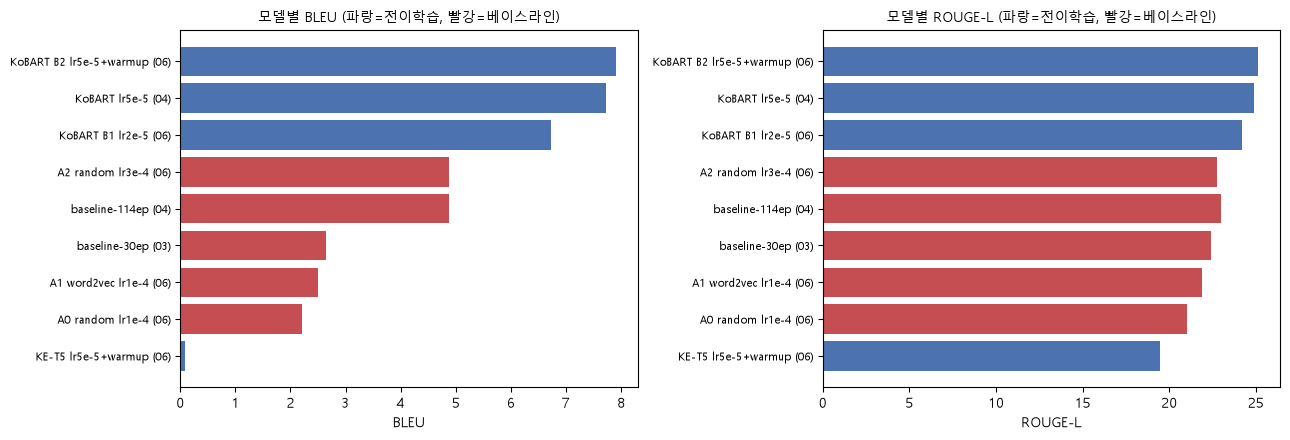

In [9]:
# 2026-09-19: 모델 비교 시각화 (BLEU/ROUGE-L 막대그래프)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_df = metrics_df.sort_values('BLEU')
colors = ['#4C72B0' if f == '전이학습' else '#C44E52' for f in plot_df['family']]

for ax, col in zip(axes, ['BLEU', 'ROUGE-L']):
    ax.barh(plot_df['model'], plot_df[col], color=colors)
    ax.set_xlabel(col)
    ax.set_title(f'모델별 {col} (파랑=전이학습, 빨강=베이스라인)', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../results/model_comparison.png', dpi=120)
plt.show()

## 5. 디코딩 전략 비교 — 05번의 8개 샘플 결론을 전체 test set으로 재검증

05번은 8개 샘플만 봤기 때문에 "beam이 낫다"는 결론이 우연일 수 있다. 여기서는 각 계열 대표 모델 하나씩(baseline-114ep, KoBART lr5e-5)에 대해 전체 1,175건으로 전략별 지표를 다시 잰다. beam 결과는 4절에서 이미 계산했으므로 재사용한다.

In [10]:
# 2026-09-19: 디코딩 전략별 비교 (대표 모델 2종)
BASE_REP = 'baseline-114ep (04)'
HF_REP = 'KoBART lr5e-5 (04)'

decoding_preds = {}

model = load_baseline(BASELINE_CKPTS[BASE_REP])
decoding_preds[(BASE_REP, 'greedy')] = baseline_generate_all(model, questions, 'greedy')
decoding_preds[(BASE_REP, 'beam5')] = predictions[BASE_REP]
torch.manual_seed(SEED)  # sampling 재현성
decoding_preds[(BASE_REP, 'top-k50/top-p0.9')] = baseline_generate_all(model, questions, 'sampling')
del model
torch.cuda.empty_cache()

hf_rep_path, hf_rep_tok = HF_CKPTS[HF_REP]
tok = AutoTokenizer.from_pretrained(hf_rep_tok)
model = AutoModelForSeq2SeqLM.from_pretrained(hf_rep_path).to(device).eval()
decoding_preds[(HF_REP, 'greedy')] = hf_generate_all(model, tok, questions, num_beams=1, do_sample=False)
decoding_preds[(HF_REP, 'beam5')] = hf_generate_all(model, tok, questions, num_beams=5)
decoding_preds[(HF_REP, 'beam5+no_repeat_ngram3')] = predictions[HF_REP]
torch.manual_seed(SEED)
decoding_preds[(HF_REP, 'top-k50/top-p0.9')] = hf_generate_all(
    model, tok, questions, do_sample=True, top_k=50, top_p=0.9, temperature=0.8)
del model
torch.cuda.empty_cache()

decoding_rows = [{'model': name, 'decoding': strat, **compute_metrics(references, preds)}
                 for (name, strat), preds in decoding_preds.items()]
decoding_df = pd.DataFrame(decoding_rows)
decoding_df.to_csv(RESULT_DIR / 'metrics_decoding.csv', index=False, encoding='utf-8-sig')
decoding_df

baseline-greedy:   0%|          | 0/1175 [00:00<?, ?it/s]

baseline-greedy:   1%|          | 8/1175 [00:00<00:16, 71.73it/s]

baseline-greedy:   1%|▏         | 17/1175 [00:00<00:14, 78.20it/s]

baseline-greedy:   2%|▏         | 26/1175 [00:00<00:13, 82.93it/s]

baseline-greedy:   3%|▎         | 37/1175 [00:00<00:12, 90.96it/s]

...

If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,model,decoding,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,baseline-114ep (04),greedy,3.05,20.61,0.148,0.425,0.0,0.121,6.65
1,baseline-114ep (04),beam5,4.87,22.99,0.128,0.303,0.0,0.014,5.18
2,baseline-114ep (04),top-k50/top-p0.9,3.06,20.01,0.186,0.563,0.0,0.106,6.70
3,KoBART lr5e-5 (04),greedy,5.91,24.98,0.225,0.558,0.0,0.026,5.85
4,KoBART lr5e-5 (04),beam5,7.71,24.68,0.206,0.481,0.0,0.024,6.33
5,KoBART lr5e-5 (04),beam5+no_repeat_ngram3,7.72,24.90,0.208,0.486,0.0,0.024,6.28
6,KoBART lr5e-5 (04),top-k50/top-p0.9,5.01,23.47,0.239,0.608,0.0,0.026,6.04


## 6. 감정 label별 성능 — 어디서 잘하고 어디서 못하는가

01번에서 확인한 label 분포(0=일상, 1=이별, 2=사랑)를 이용해 label별로 지표를 나눠 본다. 전체 평균 하나로는 "어떤 종류의 질문에서 실패하는가"를 알 수 없고, 이 분해 결과가 08번 오류분석에서 "특정 감정대의 질문에 약하다"는 가설의 출발점이 된다.

In [11]:
# 2026-09-19: 감정 label별 지표 (대표 모델 비교)
label_rows = []
for name in [BASE_REP, HF_REP]:
    for label in sorted(test_df['label'].unique()):
        idx = test_df.index[test_df['label'] == label].tolist()
        refs_l = [references[i] for i in idx]
        hyps_l = [predictions[name][i] for i in idx]
        label_rows.append({'model': name, 'label': label, 'n': len(idx), **compute_metrics(refs_l, hyps_l)})

label_df = pd.DataFrame(label_rows)
label_df.to_csv(RESULT_DIR / 'metrics_by_label.csv', index=False, encoding='utf-8-sig')
label_df

That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


...

If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


That's 100 lines that end in a tokenized period ('.')


It looks like you forgot to detokenize your test data, which may hurt your score.


If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


,model,label,n,BLEU,ROUGE-L,Distinct-1,Distinct-2,빈응답비율,연속반복률,평균길이
0,baseline-114ep (04),0,529,8.05,25.57,0.206,0.428,0.0,0.008,5.05
1,baseline-114ep (04),1,350,2.46,21.75,0.223,0.440,0.0,0.020,5.22
2,baseline-114ep (04),2,296,2.44,19.85,0.213,0.423,0.0,0.020,5.36
3,KoBART lr5e-5 (04),0,529,13.22,28.73,0.304,0.607,0.0,0.025,5.86
4,KoBART lr5e-5 (04),1,350,3.55,23.05,0.256,0.505,0.0,0.034,6.41
5,KoBART lr5e-5 (04),2,296,3.64,20.22,0.321,0.642,0.0,0.010,6.89


## 7. 생성 예시 — 숫자 뒤의 실제 문장

지표만 보면 "무엇이 좋아졌는지"가 손에 잡히지 않는다. 03/04/05번과 동일한 8개 질문에 대해 주요 모델의 실제 출력을 나란히 본다.

In [12]:
# 2026-09-19: 동일 질문에 대한 모델별 생성 비교 (03/04/05번과 같은 random_state=42 샘플)
sample_idx = test_df.sample(8, random_state=42).index.tolist()
for i in sample_idx:
    print(f"Q: {questions[i]}")
    print(f"  [정답]                        {references[i]}")
    for name in ['baseline-30ep (03)', 'baseline-114ep (04)', 'KoBART lr5e-5 (04)', 'KE-T5 lr5e-5+warmup (06)']:
        print(f"  [{name:<28}] {predictions[name][i]}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
  [정답]                        자신과 마음이 맞는 좋은 사람 만나세요.
  [baseline-30ep (03)          ] 수 있을 거예요.
  [baseline-114ep (04)         ] 잘 지내고 있을 거예요.
  [KoBART lr5e-5 (04)          ] 그런 친구 만나지 마세요.
  [KE-T5 lr5e-5+warmup (06)    ] 울어도 괜찮아요.

Q: 정장 한 벌 필요할 듯
  [정답]                        사면 요긴하긴 할 거 같아요.
  [baseline-30ep (03)          ] 다른 수 있을 거예요.
  [baseline-114ep (04)         ] 마음에 드는걸로 하세요.
  [KoBART lr5e-5 (04)          ] 정리가 잘 되길 바랄게요.
  [KE-T5 lr5e-5+warmup (06)    ] 울어도 괜찮아요.

Q: 베터리 겨우 15%야
  [정답]                        미리 충전하세요.
  [baseline-30ep (03)          ] 지지 않아요.
  [baseline-114ep (04)         ] 미리 충전하세요.
  [KoBART lr5e-5 (04)          ] 충전하고 만나요.
  [KE-T5 lr5e-5+warmup (06)    ] 울어도 괜찮아요.

Q: 오늘 생각보다 춥네
  [정답]                        감기 조심하세요.
  [baseline-30ep (03)          ] 잘 될 거예요.
  [baseline-114ep (04)         ] 그런 친구는 거르세요.
  [KoBART lr5e-5 (04)          ] 마음 감기조심하세요.
  [KE-T5 lr5e-5+warmup (06)    ] 울어도 괜찮아요.

Q: 이젠 진짜 진짜 안녕
  [정답]               

In [13]:
# 2026-09-19: 최종 지표를 JSON으로도 저장 (보고서/발표자료에서 값 인용용)
summary = {
    'test_size': len(test_df),
    'decoding': {'baseline': 'beam5(length_penalty=0.7)', 'pretrained': 'beam5+no_repeat_ngram_size=3'},
    'metric_tokenization': 'Okt 형태소 단위',
    'models': metrics_df.to_dict(orient='records'),
    'decoding_comparison': decoding_df.to_dict(orient='records'),
    'by_label': label_df.to_dict(orient='records'),
}
with open(RESULT_DIR / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('저장 완료:')
for p in sorted(RESULT_DIR.glob('*')):
    print(' -', p.name)

저장 완료:
 - before_eos_fix
 - eos_fix_comparison.csv
 - eos_fix_comparison.png
 - error_analysis.csv
 - error_by_label.csv
 - error_improvement_tracking.csv
 - error_type_distribution.csv
 - error_type_distribution.png
 - length_diagnosis.csv
 - metrics_all_models.csv
 - metrics_by_label.csv
 - metrics_decoding.csv
 - metrics_summary.json
 - model_comparison.png
 - predictions_all.csv
 - representative_error_cases.csv


## 8. EOS 수정 전후 비교 — 통제 실험

이 프로젝트에서 가장 큰 개선은 모델을 바꿔서 얻은 것이 아니라 **결함 하나를 고쳐서** 얻었다. 그 과정을 기록으로 남긴다.

**발견 경위**: 최초 실행(2026-09-19 오전)에서 이 노트북의 평가 결과는 사전 예상과 정반대였다 — 처음부터 학습한 베이스라인이 사전학습 KoBART보다 BLEU/ROUGE-L이 높았다. 08번 오류분석에서 원인을 추적한 결과, KoBART 응답의 **정상 문장 종결률이 32.3%에 불과**하고 평균 길이가 정답의 2배라는 것을 발견했고, 그 근본 원인이 **파인튜닝 타깃에 EOS 토큰이 없었던 것**임을 확인했다.

**무엇을 바꿨나**: `gogamza/kobart-base-v2` 토크나이저는 `text_target=`으로 인코딩할 때 EOS를 붙이지 않는다. 04/06번의 collate 함수에서 타깃 끝에 EOS를 추가하도록 고쳤다. **그 외 모델·learning rate·배치 크기·epoch·시드는 전부 그대로**이므로, 아래 비교는 "EOS 하나만 바꿨을 때 무엇이 달라지는가"에 대한 통제 실험이다.

수정 전 결과는 `results/before_eos_fix/`에 보관해두었다.

In [14]:
# 2026-09-19: 수정 전/후 지표를 같은 표에서 비교
before_dir = RESULT_DIR / 'before_eos_fix'
before_metrics = pd.read_csv(before_dir / 'metrics_all_models.csv')
before_preds = pd.read_csv(before_dir / 'predictions_all.csv')
before_preds['A_pred'] = before_preds['A_pred'].fillna('')

# 문장이 제대로 끝났는지 = 문장부호 또는 한국어 종결어미로 끝나는가
SENT_END = ('.', '!', '?', '요', '다', '네', '죠', '까', '용')


def end_rate(series):
    return round(series.str.strip().str.endswith(SENT_END).mean() * 100, 1)


rows = []
for name in HF_CKPTS:  # EOS 수정의 영향을 받는 것은 전이학습 계열뿐이다
    b = before_metrics[before_metrics['model'] == name].iloc[0]
    a = metrics_df[metrics_df['model'] == name].iloc[0]
    rows.append({
        'model': name,
        'BLEU(전)': b['BLEU'], 'BLEU(후)': a['BLEU'],
        'ROUGE-L(전)': b['ROUGE-L'], 'ROUGE-L(후)': a['ROUGE-L'],
        '평균길이(전)': b['평균길이'], '평균길이(후)': a['평균길이'],
        '정상종결%(전)': end_rate(before_preds[before_preds['model'] == name]['A_pred']),
        '정상종결%(후)': end_rate(pd.Series(predictions[name])),
    })

# 비교 기준선: 베이스라인은 이번 수정과 무관하므로 값이 그대로여야 한다 (통제가 지켜졌는지 확인용)
b = before_metrics[before_metrics['model'] == BASE_REP].iloc[0]
a = metrics_df[metrics_df['model'] == BASE_REP].iloc[0]
rows.append({
    'model': f'[대조군] {BASE_REP}',
    'BLEU(전)': b['BLEU'], 'BLEU(후)': a['BLEU'],
    'ROUGE-L(전)': b['ROUGE-L'], 'ROUGE-L(후)': a['ROUGE-L'],
    '평균길이(전)': b['평균길이'], '평균길이(후)': a['평균길이'],
    '정상종결%(전)': end_rate(before_preds[before_preds['model'] == BASE_REP]['A_pred']),
    '정상종결%(후)': end_rate(pd.Series(predictions[BASE_REP])),
})

compare_df = pd.DataFrame(rows)
compare_df.to_csv(RESULT_DIR / 'eos_fix_comparison.csv', index=False, encoding='utf-8-sig')
compare_df

,model,BLEU(전),BLEU(후),ROUGE-L(전),ROUGE-L(후),평균길이(전),평균길이(후),정상종결%(전),정상종결%(후)
0,KoBART lr5e-5 (04),3.83,7.72,17.54,24.90,12.32,6.28,32.3,98.0
1,KoBART B1 lr2e-5 (06),3.26,6.72,17.38,24.18,12.23,6.21,35.1,98.6
2,KoBART B2 lr5e-5+warmup (06),3.38,7.90,17.30,25.14,12.31,6.22,34.6,98.4
3,KE-T5 lr5e-5+warmup (06),0.09,0.09,19.47,19.47,4.00,4.00,100.0,100.0
4,[대조군] baseline-114ep (04),4.87,4.87,22.99,22.99,5.18,5.18,99.6,99.6


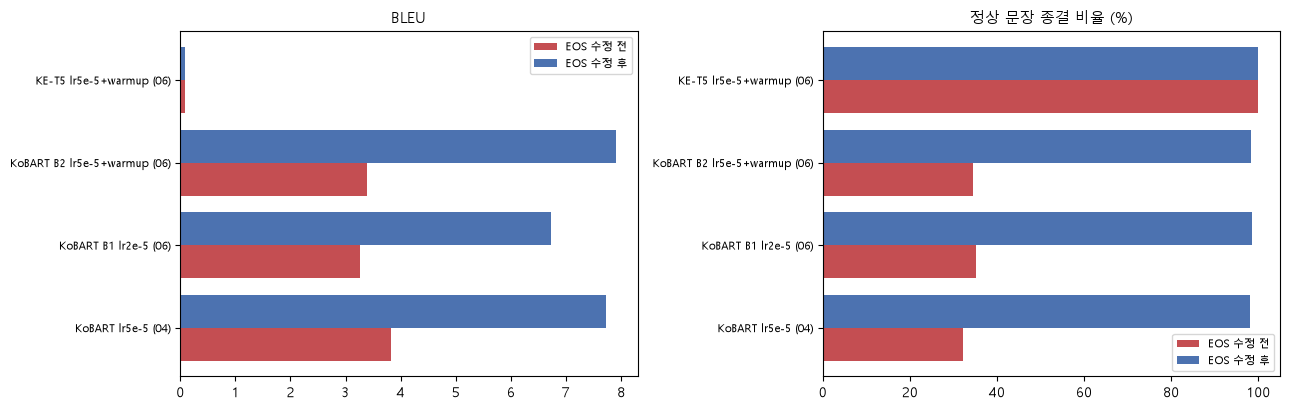

In [15]:
# 2026-09-19: 수정 전후 BLEU 변화 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
plot_src = compare_df[~compare_df['model'].str.startswith('[대조군]')]
y = np.arange(len(plot_src))

for ax, (col_b, col_a, title) in zip(axes, [('BLEU(전)', 'BLEU(후)', 'BLEU'),
                                            ('정상종결%(전)', '정상종결%(후)', '정상 문장 종결 비율 (%)')]):
    ax.barh(y - 0.2, plot_src[col_b], height=0.4, label='EOS 수정 전', color='#C44E52')
    ax.barh(y + 0.2, plot_src[col_a], height=0.4, label='EOS 수정 후', color='#4C72B0')
    ax.set_yticks(y)
    ax.set_yticklabels(plot_src['model'], fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/eos_fix_comparison.png', dpi=120)
plt.show()

In [16]:
# 2026-09-19: 같은 질문에 대한 수정 전/후 생성 비교 (정성 확인)
for i in sample_idx[:5]:
    q = questions[i]
    before_txt = before_preds[(before_preds['model'] == HF_REP) & (before_preds['Q'] == q)]['A_pred'].values
    print(f'Q: {q}')
    print(f'  [정답]   {references[i]}')
    print(f'  [수정 전] {before_txt[0] if len(before_txt) else "(없음)"}')
    print(f'  [수정 후] {predictions[HF_REP][i]}')
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
  [정답]   자신과 마음이 맞는 좋은 사람 만나세요.
  [수정 전] 상대방을 헷갈리게 하는건 좋지 않아요. 자신을 더 사랑
  [수정 후] 그런 친구 만나지 마세요.

Q: 정장 한 벌 필요할 듯
  [정답]   사면 요긴하긴 할 거 같아요.
  [수정 전] 정리가 잘 되길 바랄게요. 필요하다면 정원을 채워보
  [수정 후] 정리가 잘 되길 바랄게요.

Q: 베터리 겨우 15%야
  [정답]   미리 충전하세요.
  [수정 전] 충전하고 만나요! 기다려보세요. 기다릴게요. 기다려주
  [수정 후] 충전하고 만나요.

Q: 오늘 생각보다 춥네
  [정답]   감기 조심하세요.
  [수정 전] 마음 감기조심하세요. 따뜻하게 겨울 나길 바랄
  [수정 후] 마음 감기조심하세요.

Q: 이젠 진짜 진짜 안녕
  [정답]   맘 고생 많았어요.
  [수정 전] 안녕.. 당신은 소중한 사람이에요. 행복하세요. 당신은 행복하
  [수정 후] 맘고생 많았어요.



## 요약

**평가 조건**: test set 1,175건 전체 / 지표는 Okt 형태소 단위 / 디코딩은 베이스라인 beam5, 전이학습 beam5 + no_repeat_ngram=3 고정.

### 실측 결과 (BLEU 내림차순)

| 모델 | 계열 | BLEU | ROUGE-L | Distinct-1 | Distinct-2 | 연속반복률 | 평균길이 |
|---|---|---|---|---|---|---|---|
| **KoBART B2 lr5e-5+warmup (06)** | 전이학습 | **7.90** | **25.14** | 0.223 | **0.510** | 0.017 | 6.22 |
| KoBART lr5e-5 (04) | 전이학습 | 7.72 | 24.90 | 0.208 | 0.486 | 0.024 | 6.28 |
| KoBART B1 lr2e-5 (06) | 전이학습 | 6.72 | 24.18 | 0.218 | 0.496 | 0.031 | 6.21 |
| A2 random lr3e-4 (06) | 베이스라인 | 4.87 | 22.78 | 0.110 | 0.239 | 0.003 | 5.18 |
| baseline-114ep (04) | 베이스라인 | 4.87 | 22.99 | 0.128 | 0.303 | 0.014 | 5.18 |
| baseline-30ep (03) | 베이스라인 | 2.64 | 22.43 | 0.027 | 0.070 | 0.083 | 4.54 |
| A1 word2vec lr1e-4 (06) | 베이스라인 | 2.50 | 21.92 | 0.080 | 0.201 | 0.017 | 5.14 |
| A0 random lr1e-4 (06) | 베이스라인 | 2.21 | 21.04 | 0.048 | 0.100 | 0.008 | 5.18 |
| KE-T5 lr5e-5+warmup (06) | 전이학습 | 0.09 | 19.47 | 0.002 | 0.003 | 0.000 | 4.00 |

빈 응답 비율은 9개 모델 모두 0.000이었다 (test 정답 평균 길이는 6.46형태소).

### 세 가지 핵심 질문에 대한 답

**1. 전이학습이 실제로 더 나은가 → 그렇다. 모든 지표에서 명확히 앞선다.**

| | 최고 전이학습 (KoBART B2) | 최고 베이스라인 (114ep) | 차이 |
|---|---|---|---|
| BLEU | **7.90** | 4.87 | **+62%** |
| ROUGE-L | **25.14** | 22.99 | +9% |
| Distinct-2 (다양성) | **0.510** | 0.303 | **+68%** |
| 평균 길이 (정답 6.46) | 6.22 | 5.18 | 정답에 더 근접 |

KoBART 계열 3종이 베이스라인 5종 전체를 앞선다. 정확도(BLEU/ROUGE)와 다양성(Distinct-n)이 **동시에** 높다는 점이 중요하다 — 보통 이 둘은 상충하는데, 전이학습은 두 축을 함께 끌어올렸다.

> **주의**: 이 결론은 8절의 EOS 결함 수정 이후의 것이다. 수정 전에는 정반대 결과(베이스라인 우세)가 나왔고, 그 원인 추적 과정이 이 프로젝트의 가장 중요한 발견이다.

**2. 06번의 val_loss 순위가 생성 품질 순위와 일치하는가 → 여전히 부분적으로만 일치한다.**

| 모델 | 06번 val_loss | 07번 BLEU | 일치? |
|---|---|---|---|
| KoBART B0 (04번) | **2.7424** (1위) | 7.72 (2위) | **불일치** |
| KoBART B2 (warmup) | 2.7479 (2위) | **7.90** (1위) | **불일치** |
| KoBART B1 (lr=2e-5) | 2.7994 (3위) | 6.72 (3위) | 일치 |
| A2 (lr=3e-4) | 5.7364 (1위/베이스라인) | 4.87 (공동 1위) | 일치 |
| A1 (word2vec init) | 5.8180 (2위) | 2.50 (4위) | **불일치** |

val_loss가 가장 낮았던 B0(2.7424)보다 **B2(2.7479)의 BLEU가 더 높았다**. 차이는 작지만, "loss 최저값이 최선의 생성 모델을 보장하지 않는다"는 것을 다시 보여준다.

가장 뚜렷한 불일치는 **A1(Word2Vec 초기화)**이다. val_loss로는 A0(5.9692)보다 확실히 나았는데(5.8180), BLEU는 2.50으로 **baseline-30ep(2.64)보다도 낮다**. 즉 임베딩 초기화가 loss는 낮췄지만 실제 생성 품질로는 이어지지 않았다. **07번을 별도 단계로 둔 이유가 여기에 있다.**

**3. 05번의 8개 샘플 디코딩 결론이 전체 test set에서도 유효한가 → 유효하다.**

| 모델 | 디코딩 | BLEU | ROUGE-L | Distinct-2 | 연속반복률 |
|---|---|---|---|---|---|
| baseline-114ep | greedy | 3.05 | 20.61 | 0.425 | 0.121 |
| baseline-114ep | **beam5** | **4.87** | **22.99** | 0.303 | 0.014 |
| baseline-114ep | top-k50/top-p0.9 | 3.06 | 20.01 | **0.563** | 0.106 |
| KoBART | greedy | 5.91 | **24.98** | 0.225 | 0.026 |
| KoBART | beam5 | 7.71 | 24.68 | 0.206 | 0.024 |
| KoBART | **beam5+no_repeat_ngram3** | **7.72** | 24.90 | 0.208 | 0.024 |
| KoBART | top-k50/top-p0.9 | 5.01 | 23.47 | **0.239** | 0.026 |

- 베이스라인에서 beam5는 greedy 대비 BLEU를 3.05 → 4.87로 **60% 끌어올렸고**, 연속반복률도 0.121 → 0.014로 거의 없앴다.
- KoBART에서도 beam5가 greedy보다 BLEU가 크게 높다(7.71 vs 5.91). 다만 **no_repeat_ngram=3의 추가 이득은 0.01에 불과**하다 — EOS 수정 후에는 억제할 반복이 거의 없어 이 설정이 사실상 무효가 됐기 때문이다(05번 요약 참조).
- sampling은 두 모델 모두 다양성은 높지만 BLEU/ROUGE는 가장 낮다 — 다양성과 정답 일치도의 상충 관계가 그대로 드러난다.

### 감정 label별 성능

| 모델 | label | n | BLEU | ROUGE-L | Distinct-2 |
|---|---|---|---|---|---|
| baseline-114ep | 0 일상 | 529 | 8.05 | 25.57 | 0.428 |
| baseline-114ep | 1 이별 | 350 | 2.46 | 21.75 | 0.440 |
| baseline-114ep | 2 사랑 | 296 | 2.44 | 19.85 | 0.423 |
| KoBART | 0 일상 | 529 | **13.22** | **28.73** | 0.607 |
| KoBART | 1 이별 | 350 | 3.55 | 23.05 | 0.505 |
| KoBART | 2 사랑 | 296 | 3.64 | 20.22 | **0.642** |

두 모델 모두 **label 0(일상)에서 압도적으로 높고 label 1·2에서 낮다**. 01번에서 확인한 데이터 쏠림(일상 5,290 / 이별 3,570 / 사랑 2,963)과 방향이 일치한다. 주목할 점은 **KoBART가 모든 label에서 베이스라인을 앞서며, 특히 label 0에서 격차가 가장 크다는 것**(13.22 vs 8.05)이다. 데이터가 많은 영역에서 사전학습의 이점이 더 크게 발현된다는 해석이 가능하다.

### 8절 — EOS 수정 전후 비교

| 모델 | BLEU 전→후 | ROUGE-L 전→후 | 평균길이 전→후 | 정상종결% 전→후 |
|---|---|---|---|---|
| KoBART lr5e-5 (04) | 3.83 → **7.72** | 17.54 → **24.90** | 12.32 → **6.28** | 32.3 → **98.0** |
| KoBART B1 lr2e-5 | 3.26 → **6.72** | 17.38 → **24.18** | 12.23 → **6.21** | 35.1 → **98.6** |
| KoBART B2 lr5e-5+warmup | 3.38 → **7.90** | 17.30 → **25.14** | 12.31 → **6.22** | 34.6 → **98.4** |
| KE-T5 | 0.09 → 0.09 | 19.47 → 19.47 | 4.00 → 4.00 | 100.0 → 100.0 |
| **[대조군] baseline-114ep** | 4.87 → 4.87 | 22.99 → 22.99 | 5.18 → 5.18 | 99.6 → 99.6 |

**EOS 하나를 고친 것만으로 KoBART의 BLEU가 2배 이상 올랐다**(3.83 → 7.72). 평균 생성 길이는 12.32 → 6.28형태소로 정답(6.46)에 거의 정확히 맞춰졌고, 정상 문장 종결률은 32.3% → 98.0%가 됐다.

**대조군 두 개가 값이 전혀 변하지 않았다는 점이 이 실험의 신뢰도를 뒷받침한다.** 베이스라인은 원래 EOS를 붙이고 있었고(03번 `encode_text`), KE-T5는 토크나이저가 EOS를 자동으로 붙여 이번 수정이 no-op였다. 즉 **결함이 있던 모델만 정확히 골라서 개선됐다.**

산출물: `results/metrics_all_models.csv`, `metrics_decoding.csv`, `metrics_by_label.csv`, `eos_fix_comparison.csv`, `predictions_all.csv`, `metrics_summary.json`, `model_comparison.png`, `eos_fix_comparison.png` (수정 전 결과는 `results/before_eos_fix/`)